<b>Example 2 : Titanic Dataset</b>

---

Section 01 : Import Libraries

In [14]:
import pickle   
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree
from sklearn.tree import _tree

---

Section 02 : Preprocess Data

In [15]:
# Load dataset
df_main = pd.read_csv('titanic.csv')
df_main

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,20.0,0,0,4.0125,C
1,0,3,male,34.5,0,0,6.4375,C
2,0,3,male,20.0,0,0,7.2250,C
3,0,3,male,21.0,0,0,7.2250,C
4,0,3,male,22.5,0,0,7.2250,C
...,...,...,...,...,...,...,...,...
1038,1,1,female,29.0,0,0,221.7792,S
1039,1,1,female,23.0,3,2,263.0000,S
1040,1,1,female,24.0,3,2,263.0000,S
1041,1,1,female,28.0,3,2,263.0000,S


In [16]:
# Assign data type
df_main['survived'] = df_main['survived'].astype('category')
df_main['pclass'] = df_main['pclass'].astype('category')
df_main['sex'] = df_main['sex'].astype('category')
df_main['age'] = df_main['age'].astype('Float64')
df_main['sibsp'] = df_main['sibsp'].astype('Int64')
df_main['parch'] = df_main['parch'].astype('Int64')
df_main['fare'] = df_main['fare'].astype('Float64')
df_main['embarked'] = df_main['embarked'].astype('category')
df_main.dtypes

survived    category
pclass      category
sex         category
age          Float64
sibsp          Int64
parch          Int64
fare         Float64
embarked    category
dtype: object

In [17]:
# Perform one-hot encoding
df_main = pd.get_dummies(df_main, dtype=int, columns=['pclass', 'sex', 'embarked'])
df_main

,survived,age,sibsp,parch,fare,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,20.0,0,0,4.0125,0,0,1,0,1,1,0,0
1,0,34.5,0,0,6.4375,0,0,1,0,1,1,0,0
2,0,20.0,0,0,7.225,0,0,1,0,1,1,0,0
3,0,21.0,0,0,7.225,0,0,1,0,1,1,0,0
4,0,22.5,0,0,7.225,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,1,29.0,0,0,221.7792,1,0,0,1,0,0,0,1
1039,1,23.0,3,2,263.0,1,0,0,1,0,0,0,1
1040,1,24.0,3,2,263.0,1,0,0,1,0,0,0,1
1041,1,28.0,3,2,263.0,1,0,0,1,0,0,0,1


In [18]:
# Perform min-max normalization
scaler = MinMaxScaler()
df_main['age'] = scaler.fit_transform(df_main[['age']])
df_main['sibsp'] = scaler.fit_transform(df_main[['sibsp']])
df_main['parch'] = scaler.fit_transform(df_main[['parch']])
df_main['fare'] = scaler.fit_transform(df_main[['fare']])
df_main

,survived,age,sibsp,parch,fare,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,0.248434,0.000,0.000000,0.007832,0,0,1,0,1,1,0,0
1,0,0.430062,0.000,0.000000,0.012565,0,0,1,0,1,1,0,0
2,0,0.248434,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
3,0,0.260960,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
4,0,0.279749,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,1,0.361169,0.000,0.000000,0.432884,1,0,0,1,0,0,0,1
1039,1,0.286012,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1
1040,1,0.298538,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1
1041,1,0.348643,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1


In [19]:
X = df_main.drop(['survived'], axis=1)
y = df_main['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=45)

---

Section 03 : Cross Validation

In [20]:
# Initial parameters
max_depth = 3
criterion = 'entropy'

# Test parameters
clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=max_depth)
scoring = ['accuracy', 'precision', 'recall', 'f1_macro']
scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)
print('fit_time       :', scores['fit_time'].mean())
print('score_time     :', scores['score_time'].mean())
print('test_accuracy  :', scores['test_accuracy'].mean())
print('test_precision :', scores['test_precision'].mean())
print('test_recall    :', scores['test_recall'].mean())
print('test_f1_macro  :', scores['test_f1_macro'].mean())

fit_time       : 0.0021111011505126954
score_time     : 0.0065536975860595705
test_accuracy  : 0.7980164439876669
test_precision : 0.7809543842682141
test_recall    : 0.667878787878788
test_f1_macro  : 0.7786555829839172


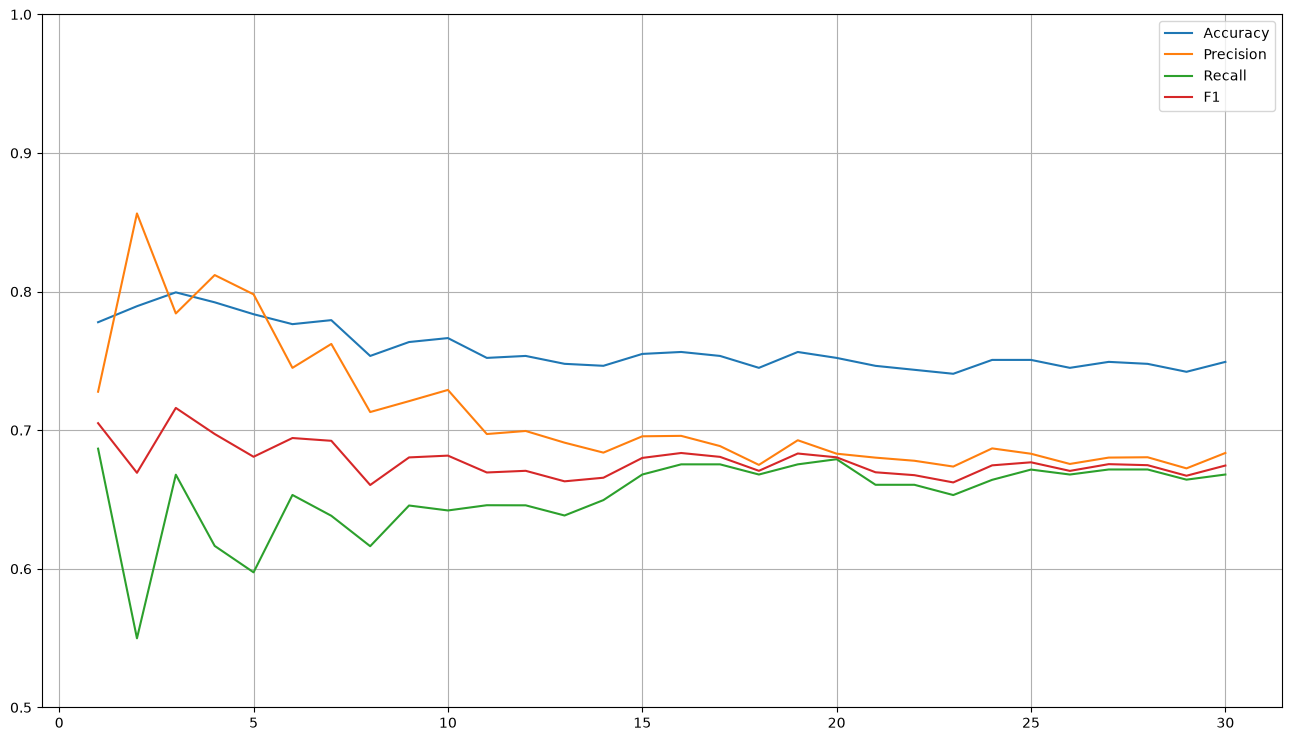

In [21]:
# Observe max_depth
max_depth = []
accuracy = []
precision = []
recall = []
f1_macro = []

# Observe algorithm
criterion = 'gini'
#criterion = 'entropy'

for i in range(1, 31):
    clf = tree.DecisionTreeClassifier(criterion=criterion, max_depth=i)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)

    max_depth.append(i)
    accuracy.append(scores['test_accuracy'].sum() / 5)
    precision.append(scores['test_precision'].sum() / 5)
    recall.append(scores['test_recall'].sum() / 5)
    f1_macro.append(scores['test_f1'].sum() / 5)

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(max_depth , accuracy)    
ax.plot(max_depth , precision)
ax.plot(max_depth , recall)
ax.plot(max_depth , f1_macro)

ax.legend(['Accuracy', 'Precision', 'Recall', 'F1'])
ax.set_ylim([0.5, 1])
ax.grid()

---

Section 04 : Build Classification Model

              precision    recall  f1-score   support

     Class 0       0.79      0.87      0.83       191
     Class 1       0.82      0.71      0.76       154

    accuracy                           0.80       345
   macro avg       0.80      0.79      0.79       345
weighted avg       0.80      0.80      0.80       345



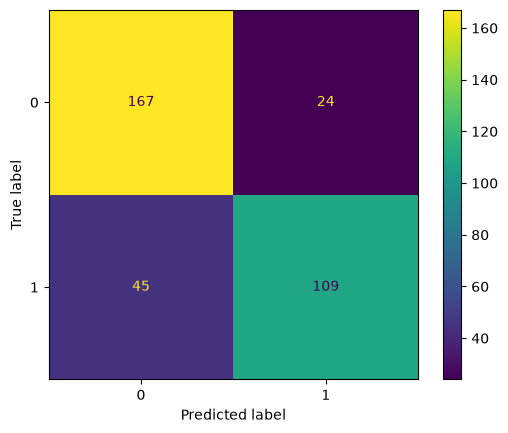

In [22]:
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
target_names = ['Class 0','Class 1']
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot();

In [23]:
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf.fit(X, y)
filename = "model_02.mod"
pickle.dump(clf, open(filename, 'wb'))

---

Section 05 : Extract Knowledge from model

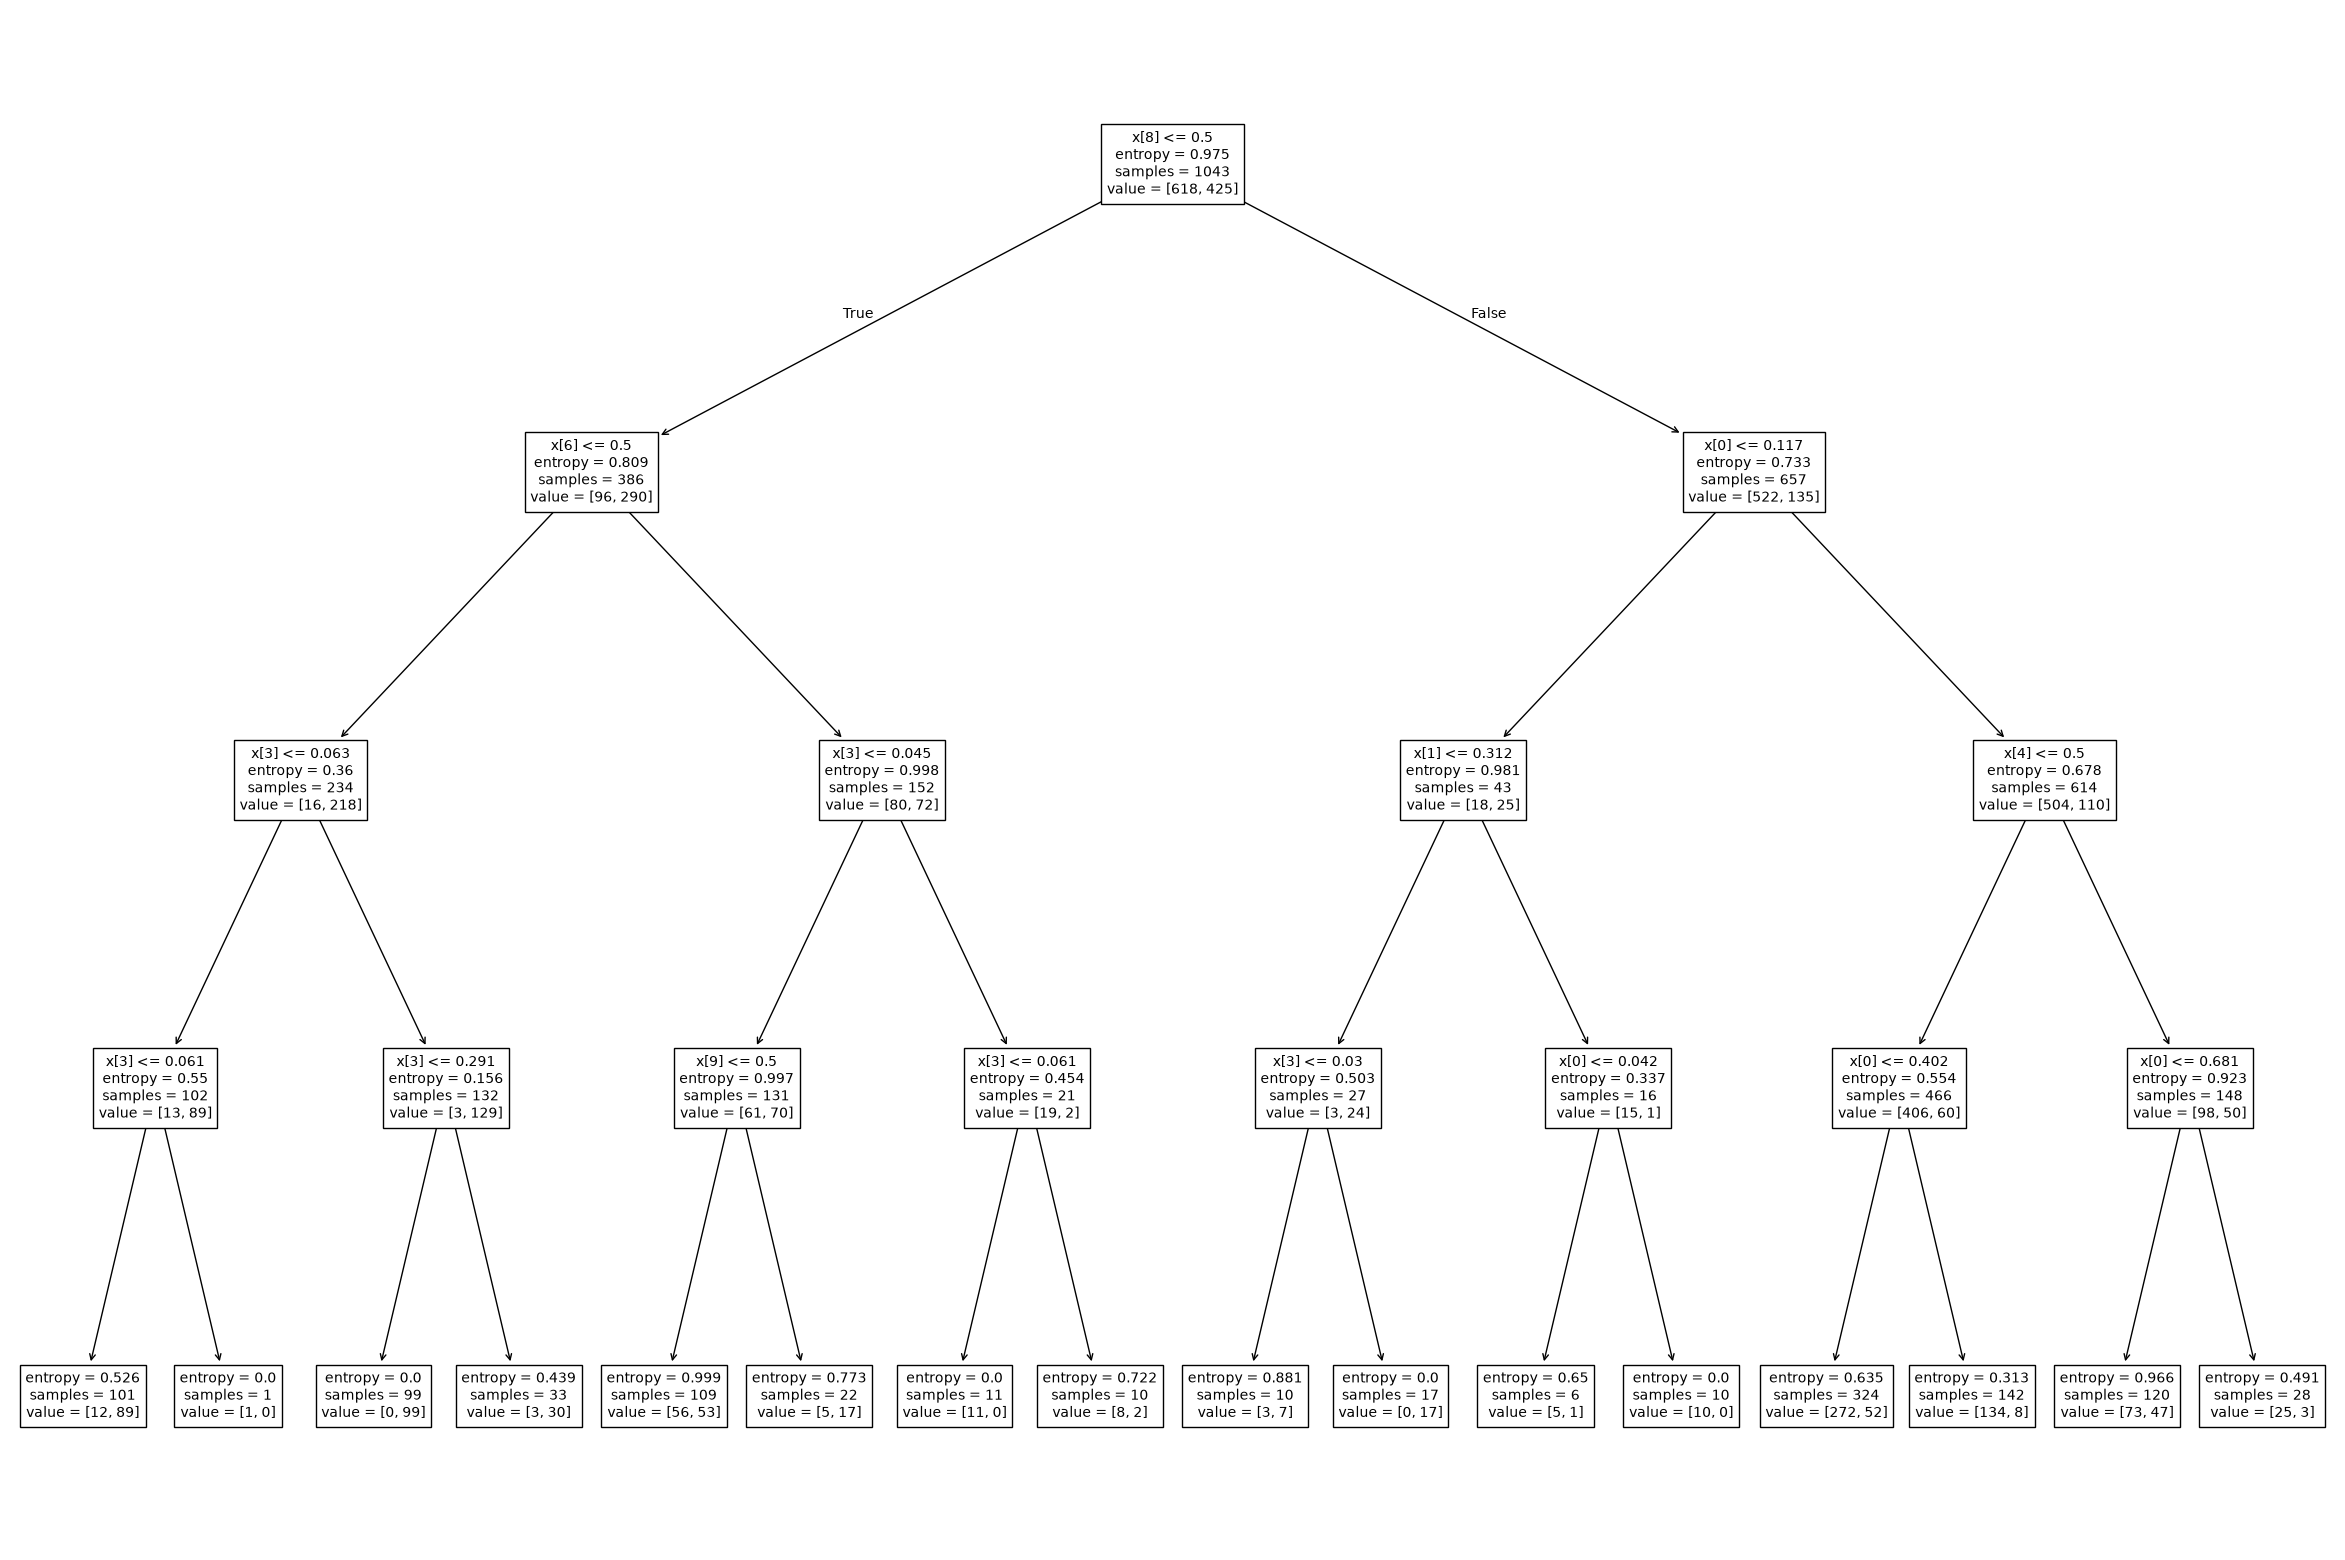

In [24]:
fig, ax = plt.subplots(figsize=(30, 20))
tree.plot_tree(clf, ax=ax);

In [25]:
text_tree = tree.export_text(clf)
print(text_tree)

|--- feature_8 <= 0.50
|   |--- feature_6 <= 0.50
|   |   |--- feature_3 <= 0.06
|   |   |   |--- feature_3 <= 0.06
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.06
|   |   |   |   |--- class: 0
|   |   |--- feature_3 >  0.06
|   |   |   |--- feature_3 <= 0.29
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.29
|   |   |   |   |--- class: 1
|   |--- feature_6 >  0.50
|   |   |--- feature_3 <= 0.05
|   |   |   |--- feature_9 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_9 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.05
|   |   |   |--- feature_3 <= 0.06
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.06
|   |   |   |   |--- class: 0
|--- feature_8 >  0.50
|   |--- feature_0 <= 0.12
|   |   |--- feature_1 <= 0.31
|   |   |   |--- feature_3 <= 0.03
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.03
|   |   |   |   |--- class: 1
|   |   |--- feature_1 >  0.31
|   |   |   |--- feature_0 <= 0.04
| 

In [26]:
def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules

feature_names = ['pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']
class_names = ['Died', 'Survived']
rules = get_rules(clf, feature_names, class_names)
for r in rules:
    print(r)

if (fare > 0.5) and (pclass_1 > 0.117) and (sex_male <= 0.5) and (pclass_1 <= 0.402) then class: Died (proba: 83.95%) | based on 324 samples
if (fare > 0.5) and (pclass_1 > 0.117) and (sex_male <= 0.5) and (pclass_1 > 0.402) then class: Died (proba: 94.37%) | based on 142 samples
if (fare > 0.5) and (pclass_1 > 0.117) and (sex_male > 0.5) and (pclass_1 <= 0.681) then class: Died (proba: 60.83%) | based on 120 samples
if (fare <= 0.5) and (sibsp > 0.5) and (sex_female <= 0.045) and (embarked_C <= 0.5) then class: Died (proba: 51.38%) | based on 109 samples
if (fare <= 0.5) and (sibsp <= 0.5) and (sex_female <= 0.063) and (sex_female <= 0.061) then class: Survived (proba: 88.12%) | based on 101 samples
if (fare <= 0.5) and (sibsp <= 0.5) and (sex_female > 0.063) and (sex_female <= 0.291) then class: Survived (proba: 100.0%) | based on 99 samples
if (fare <= 0.5) and (sibsp <= 0.5) and (sex_female > 0.063) and (sex_female > 0.291) then class: Survived (proba: 90.91%) | based on 33 samples

---

Secion 06 : Building Preprocessing Module

In [27]:
# Observe original data
df_main = pd.read_csv('titanic.csv')
df_main

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,20.0,0,0,4.0125,C
1,0,3,male,34.5,0,0,6.4375,C
2,0,3,male,20.0,0,0,7.2250,C
3,0,3,male,21.0,0,0,7.2250,C
4,0,3,male,22.5,0,0,7.2250,C
...,...,...,...,...,...,...,...,...
1038,1,1,female,29.0,0,0,221.7792,S
1039,1,1,female,23.0,3,2,263.0000,S
1040,1,1,female,24.0,3,2,263.0000,S
1041,1,1,female,28.0,3,2,263.0000,S


In [28]:
# Define feature engineeing funcion
def feature_engineer(x_org):
    
    x_tmp = {}
    
    # Engineering 'age'
    age_org = x_org['age']
    x_tmp['age'] = (age_org - 0.1667) / (80.0000 - 0.1667)

    # Engineering 'sibsp'
    sibsp_org = x_org['sibsp']
    x_tmp['sibsp'] = (sibsp_org - 0) / (8 - 0)
    
    # Engineering 'parch'
    parch_org = x_org['parch']
    x_tmp['parch'] = (parch_org - 0) / (6 - 0)

    # Engineering 'fare'
    fare_org = x_org['fare']
    x_tmp['fare'] = (fare_org - 0) / (512.329200 - 0)

    # Engineering 'pclass'
    pclass_org = x_org['pclass']
    if pclass_org == 1:
        x_tmp['pclass_1'] = 1
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 0
    elif pclass_org == 2:
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 1
        x_tmp['pclass_3'] = 0
    elif pclass_org == 3:    
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 1
    else:
        x_tmp['pclass_1'] = 0
        x_tmp['pclass_2'] = 0
        x_tmp['pclass_3'] = 1
    
    # Engineering 'sex'
    sex_org = x_org['sex']
    if sex_org == 'male':
        x_tmp['sex_female'] = 0
        x_tmp['sex_male'] = 1
    elif sex_org == 'female':
        x_tmp['sex_female'] = 1
        x_tmp['sex_male'] = 0
    else:
        x_tmp['sex_female'] = 0
        x_tmp['sex_male'] = 1

    # Engineering 'embarked'
    embared_org = x_org['embarked']
    if embared_org == 'C':
        x_tmp['embarked_C'] = 1
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 0
    elif embared_org == 'Q':
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 1
        x_tmp['embarked_S'] = 0
    elif embared_org == 'S':
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 1
    else:
        x_tmp['embarked_C'] = 0
        x_tmp['embarked_Q'] = 0
        x_tmp['embarked_S'] = 1

    return x_tmp

# Loop for feature engineering
df_final = pd.DataFrame()
for i in range(0, df_main.shape[0]):
    
    x_org = df_main.iloc[i, 1:]
    x_prc = feature_engineer(x_org)
    
    df_tmp = pd.DataFrame([x_prc])
    df_final = pd.concat([df_final, df_tmp])

df_final

,age,sibsp,parch,fare,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0.248434,0.000,0.000000,0.007832,0,0,1,0,1,1,0,0
0,0.430062,0.000,0.000000,0.012565,0,0,1,0,1,1,0,0
0,0.248434,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
0,0.260960,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
0,0.279749,0.000,0.000000,0.014102,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.361169,0.000,0.000000,0.432884,1,0,0,1,0,0,0,1
0,0.286012,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1
0,0.298538,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1
0,0.348643,0.375,0.333333,0.513342,1,0,0,1,0,0,0,1


---

Section 07 : Building Prediction Module

In [29]:
# Prepare function for prediction model to production
tree_mod = pickle.load(open("model_02.mod", 'rb'))

def model_predic(X):
    y = tree_mod.predict(df_final)
    return(y)

y_pred = model_predic(df_final)
y_pred

array([0, 0, 0, ..., 1, 1, 1], shape=(1043,))

---